# Prefix Tree (Radix Tree) Visualization and Demonstration

This notebook demonstrates the functionality of the multi-tenant prefix tree implementation. We'll visualize the tree structure at various stages to understand how it works.

In [1]:
# Import the Tree implementation
from ray.llm._internal.serve.deployments.routers.prefix_tree import PrefixTree, Node
import time
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import pandas as pd

# Install required packages if not already installed
!pip install -q networkx matplotlib pandas

## Helper Functions for Tree Visualization

In [2]:
def visualize_tree(tree, title="Prefix Tree Visualization"):
    """
    Visualize the tree structure using networkx and matplotlib.
    
    Args:
        tree: The Tree object to visualize
        title: Title for the visualization
    """
    G = nx.DiGraph()
    
    # Use BFS to traverse the tree and build the graph
    queue = [(tree.root, "root")]
    visited = set()
    
    while queue:
        node, node_id = queue.pop(0)
        if node in visited:
            continue
            
        visited.add(node)
        
        # Add node to graph
        label = f"{node.text}\n{list(node.tenant_last_access_time.keys())}"
        G.add_node(node_id, label=label)
        
        # Add edges to children
        for char, child in node.children.items():
            child_id = f"{node_id}_{char}"
            queue.append((child, child_id))
            G.add_edge(node_id, child_id, label=char)
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42)  # Consistent layout
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="lightblue", alpha=0.8)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)
    
    # Draw labels
    node_labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10)
    
    # Draw edge labels
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
    
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def print_tree_structure(tree):
    """
    Print the tree structure in a readable format.
    
    Args:
        tree: The Tree object to print
    """
    def _print_node(node, prefix="", is_last=True, depth=0):
        # Print current node
        branch = "└── " if is_last else "├── "
        print(f"{prefix}{branch}{node.text} {list(node.tenant_last_access_time.keys())}")
        
        # Prepare prefix for children
        prefix += "    " if is_last else "│   "
        
        # Print children
        children = list(node.children.items())
        for i, (char, child) in enumerate(children):
            _print_node(child, prefix, i == len(children) - 1, depth + 1)
    
    print("Tree Structure:")
    print(f"Root {list(tree.root.tenant_last_access_time.keys())}")
    
    children = list(tree.root.children.items())
    for i, (char, child) in enumerate(children):
        _print_node(child, "", i == len(children) - 1)
        
def display_tenant_stats(tree):
    """
    Display statistics about tenants in the tree.
    
    Args:
        tree: The Tree object to analyze
    """
    tenant_counts = tree.get_tenant_char_count()
    
    if not tenant_counts:
        print("No tenants in the tree.")
        return
    
    df = pd.DataFrame({
        'Tenant': list(tenant_counts.keys()),
        'Character Count': list(tenant_counts.values())
    })
    
    # Sort by character count
    df = df.sort_values('Character Count', ascending=False).reset_index(drop=True)
    
    # Add a column for percentage of total
    total_chars = df['Character Count'].sum()
    df['Percentage'] = (df['Character Count'] / total_chars * 100).round(2)
    
    # Add styling
    styled_df = df.style.background_gradient(subset=['Character Count', 'Percentage'])
    display(styled_df)
    
    # Print the smallest tenant
    smallest_tenant = tree.get_smallest_tenant()
    print(f"Smallest tenant: {smallest_tenant}")

## 1. Creating a Tree and Basic Insertion

Tree Structure:
Root ['A']
└── hello ['A']


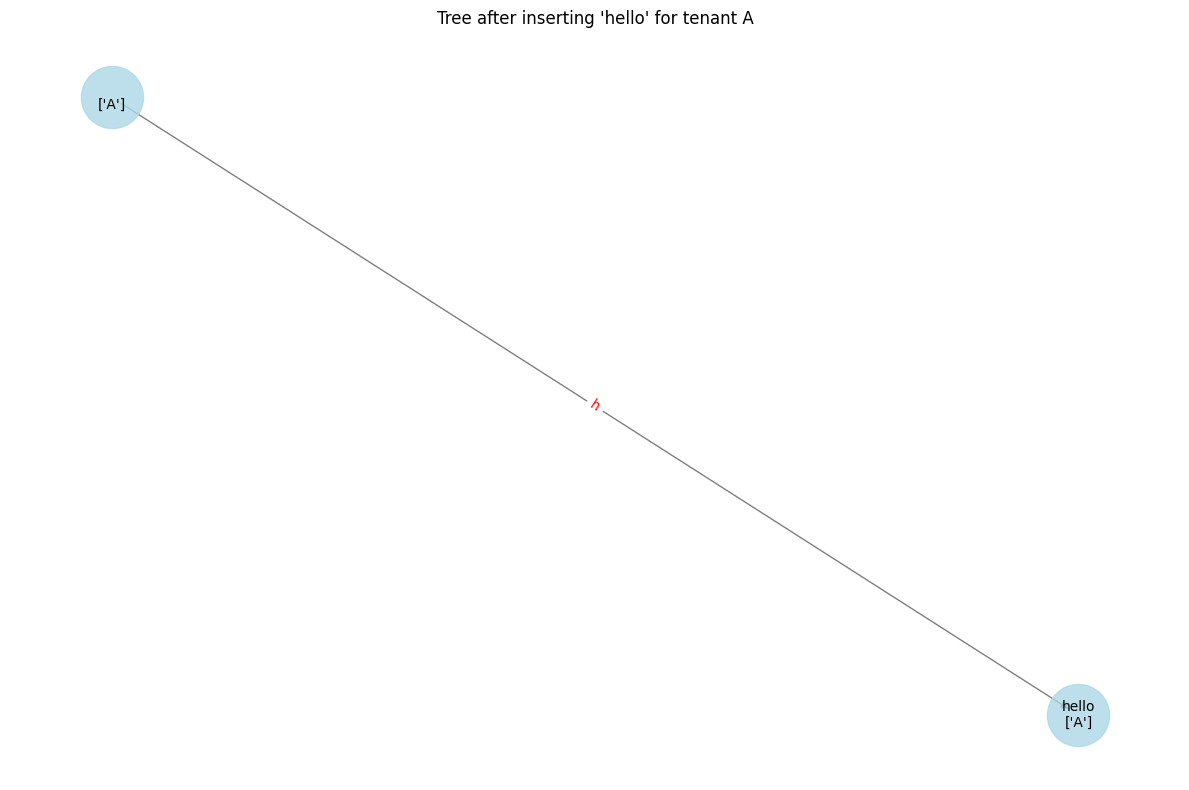

Tree Structure:
Root ['A']
└── hel ['A']
    ├── lo ['A']
    └── p ['A']


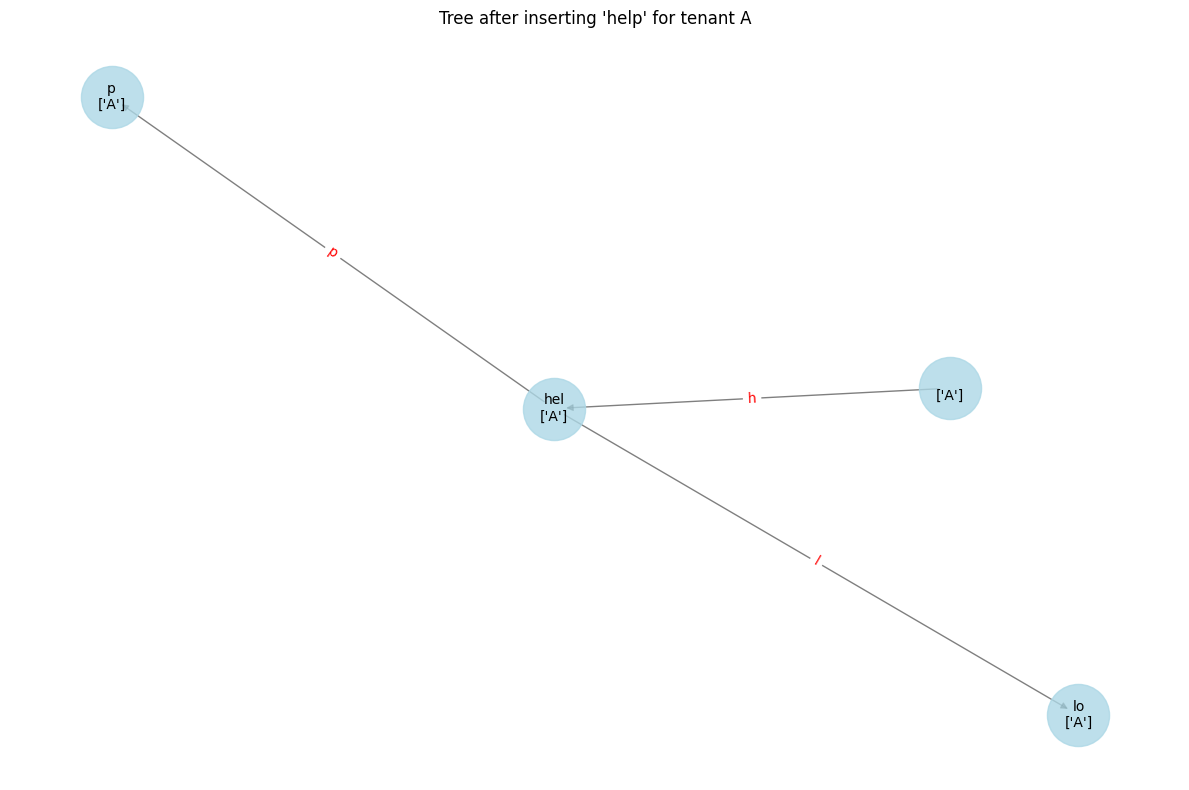

Tree Structure:
Root ['A']
├── hel ['A']
│   ├── lo ['A']
│   └── p ['A']
└── world ['A']


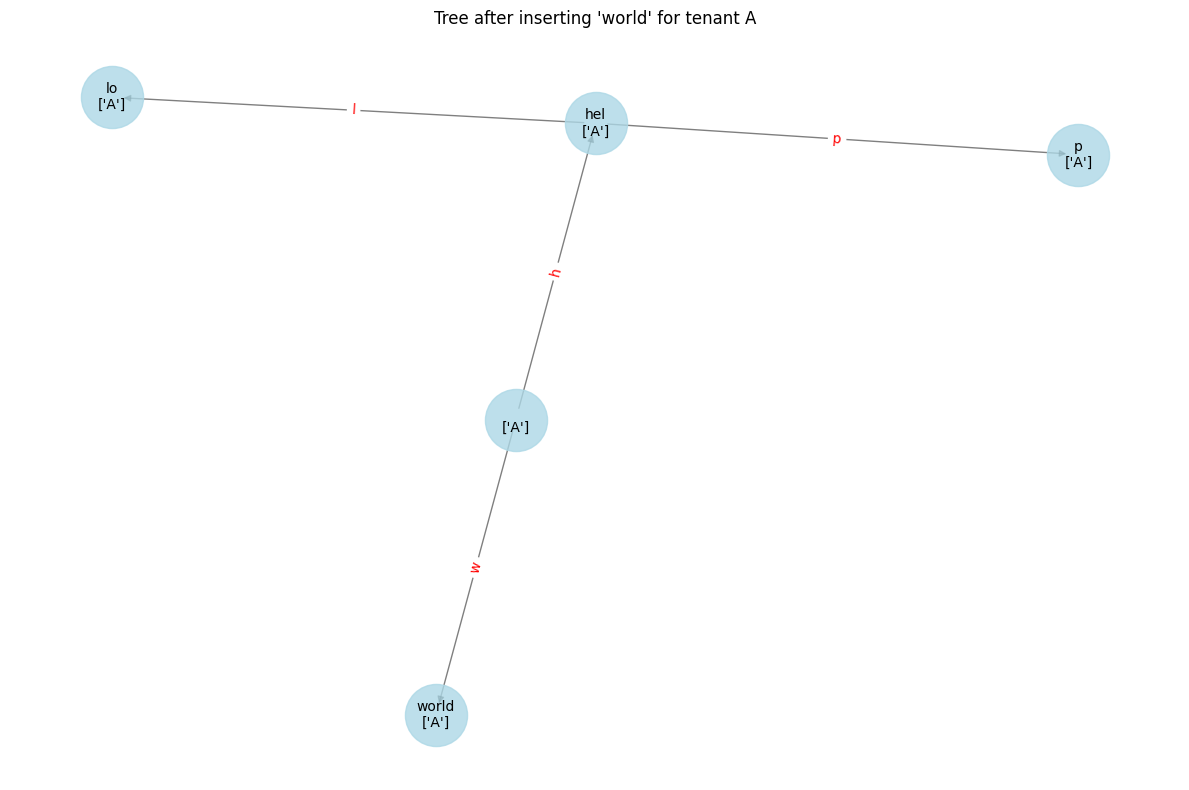

,Tenant,Character Count,Percentage
0,A,11,100.000000


Smallest tenant: A


In [3]:
# Create a new tree
tree = PrefixTree()

# Let's insert some simple strings for tenant "A"
tree.insert("hello", "A")

# Visualize the tree after first insertion
print_tree_structure(tree)
visualize_tree(tree, "Tree after inserting 'hello' for tenant A")

# Insert another string with a shared prefix
tree.insert("help", "A")

# Visualize the tree after second insertion
print_tree_structure(tree)
visualize_tree(tree, "Tree after inserting 'help' for tenant A")

# Insert a completely different string
tree.insert("world", "A")

# Visualize the tree after third insertion
print_tree_structure(tree)
visualize_tree(tree, "Tree after inserting 'world' for tenant A")

# Display tenant statistics
display_tenant_stats(tree)

## 2. Multi-Tenant Insertion

Tree Structure:
Root ['A', 'B']
├── hel ['A', 'B']
│   ├── lo ['A']
│   ├── p ['A']
│   └── icopter ['B']
└── world ['A']


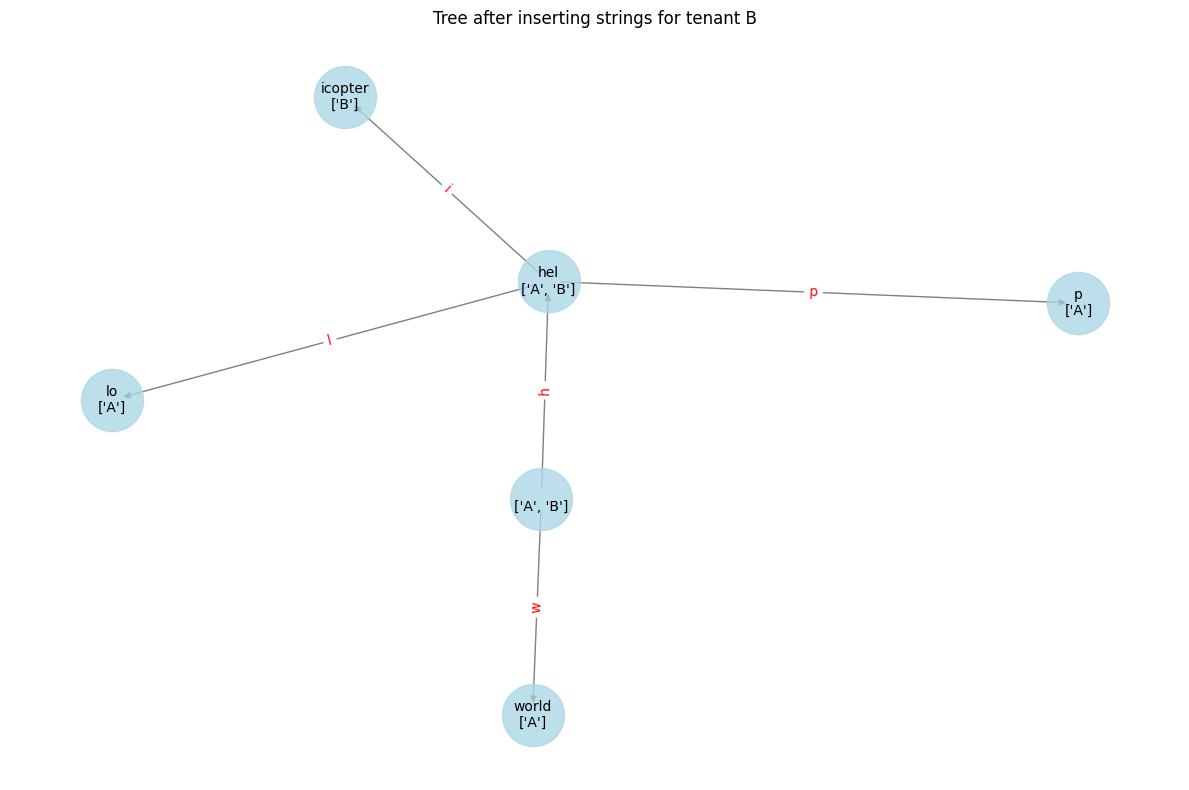

Tree Structure:
Root ['A', 'B', 'C']
├── hel ['A', 'B']
│   ├── lo ['A']
│   ├── p ['A']
│   └── icopter ['B']
├── world ['A']
└── p ['C']
    ├── ython ['C']
    └── rogramming ['C']


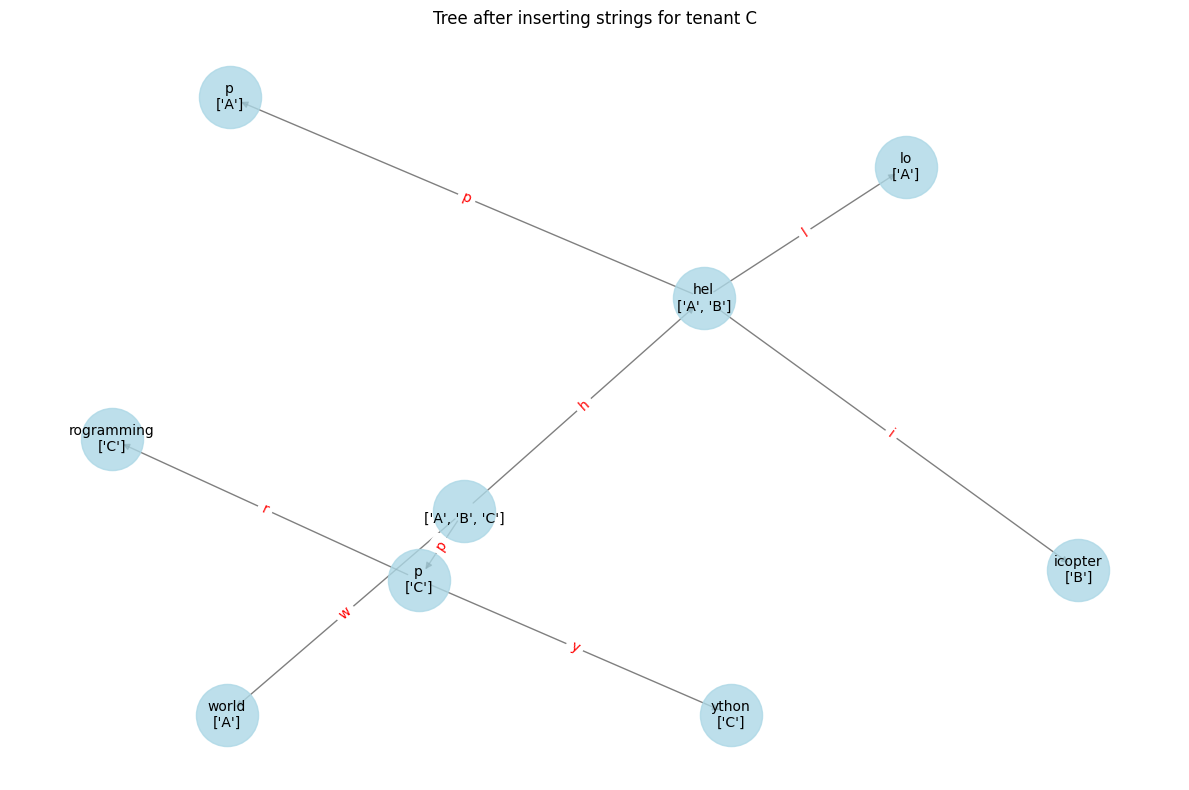

,Tenant,Character Count,Percentage
0,C,16,41.030000
1,B,12,30.770000
2,A,11,28.210000


Smallest tenant: A


In [4]:
# Insert strings for tenant "B"
tree.insert("hello", "B")  # Same string as tenant A
tree.insert("helicopter", "B")  # Shares prefix with existing nodes

# Visualize the tree after multi-tenant insertion
print_tree_structure(tree)
visualize_tree(tree, "Tree after inserting strings for tenant B")

# Insert strings for tenant "C"
tree.insert("python", "C")
tree.insert("programming", "C")

# Visualize the tree after adding tenant C
print_tree_structure(tree)
visualize_tree(tree, "Tree after inserting strings for tenant C")

# Display tenant statistics
display_tenant_stats(tree)

## 3. Prefix Matching

In [6]:
# Test prefix matching
test_strings = [
    "hello world",
    "help me",
    "helicopter pilot",
    "python code",
    "program",
    "nothing"
]

print("General prefix matching (any tenant):")
for test_str in test_strings:
    matched_text, tenant = tree.prefix_match(test_str)
    print(f"Input: '{test_str}' → Matched: '{matched_text}' (Tenant: {tenant})")

print("\nTenant-specific prefix matching:")
for tenant in ["A", "B", "C"]:
    print(f"\nMatching for tenant {tenant}:")
    for test_str in test_strings:
        matched_text = tree.prefix_match_tenant(test_str, tenant)
        print(f"Input: '{test_str}' → Matched: '{matched_text}'")

General prefix matching (any tenant):
Input: 'hello world' → Matched: 'hello' (Tenant: A)
Input: 'help me' → Matched: 'help' (Tenant: A)
Input: 'helicopter pilot' → Matched: 'helicopter' (Tenant: B)
Input: 'python code' → Matched: 'python' (Tenant: C)
Input: 'program' → Matched: 'program' (Tenant: C)
Input: 'nothing' → Matched: '' (Tenant: A)

Tenant-specific prefix matching:

Matching for tenant A:
Input: 'hello world' → Matched: 'hello'
Input: 'help me' → Matched: 'help'
Input: 'helicopter pilot' → Matched: 'hel'
Input: 'python code' → Matched: ''
Input: 'program' → Matched: ''
Input: 'nothing' → Matched: ''

Matching for tenant B:
Input: 'hello world' → Matched: 'hel'
Input: 'help me' → Matched: 'hel'
Input: 'helicopter pilot' → Matched: 'helicopter'
Input: 'python code' → Matched: ''
Input: 'program' → Matched: ''
Input: 'nothing' → Matched: ''

Matching for tenant C:
Input: 'hello world' → Matched: ''
Input: 'help me' → Matched: ''
Input: 'helicopter pilot' → Matched: ''
Input: 'p

## 4. Tenant Management

In [6]:
# Check tenant character counts
print("Initial tenant character counts:")
display_tenant_stats(tree)

# Get the smallest tenant
smallest_tenant = tree.get_smallest_tenant()
print(f"Smallest tenant: {smallest_tenant}")

# Add more data for the smallest tenant to make it larger
if smallest_tenant != "empty":
    tree.insert("supercalifragilisticexpialidocious", smallest_tenant)
    print(f"\nAfter adding a long string to tenant {smallest_tenant}:")
    display_tenant_stats(tree)

# Test eviction
print("\nBefore eviction:")
total_chars = sum(tree.get_tenant_char_count().values())
print(f"Total characters in tree: {total_chars}")

# Set max size to 75% of current size to trigger eviction
max_size = int(total_chars * 0.75)
print(f"Setting max size to {max_size} characters")
tree.evict_tenant_by_size(max_size)

print("\nAfter eviction:")
display_tenant_stats(tree)

Initial tenant character counts:


,Tenant,Character Count,Percentage
0,C,16,41.030000
1,B,12,30.770000
2,A,11,28.210000


Smallest tenant: A
Smallest tenant: A

After adding a long string to tenant A:


,Tenant,Character Count,Percentage
0,A,45,61.640000
1,C,16,21.920000
2,B,12,16.440000


Smallest tenant: B

Before eviction:
Total characters in tree: 73
Setting max size to 54 characters
Evicting 19 chars from tenant A
Tree eviction complete. New size: 54

After eviction:


,Tenant,Character Count,Percentage
0,A,26,48.150000
1,C,16,29.630000
2,B,12,22.220000


Smallest tenant: B


## 5. Removing a Tenant

Before removing tenant:


,Tenant,Character Count,Percentage
0,A,26,48.150000
1,C,16,29.630000
2,B,12,22.220000


Smallest tenant: B


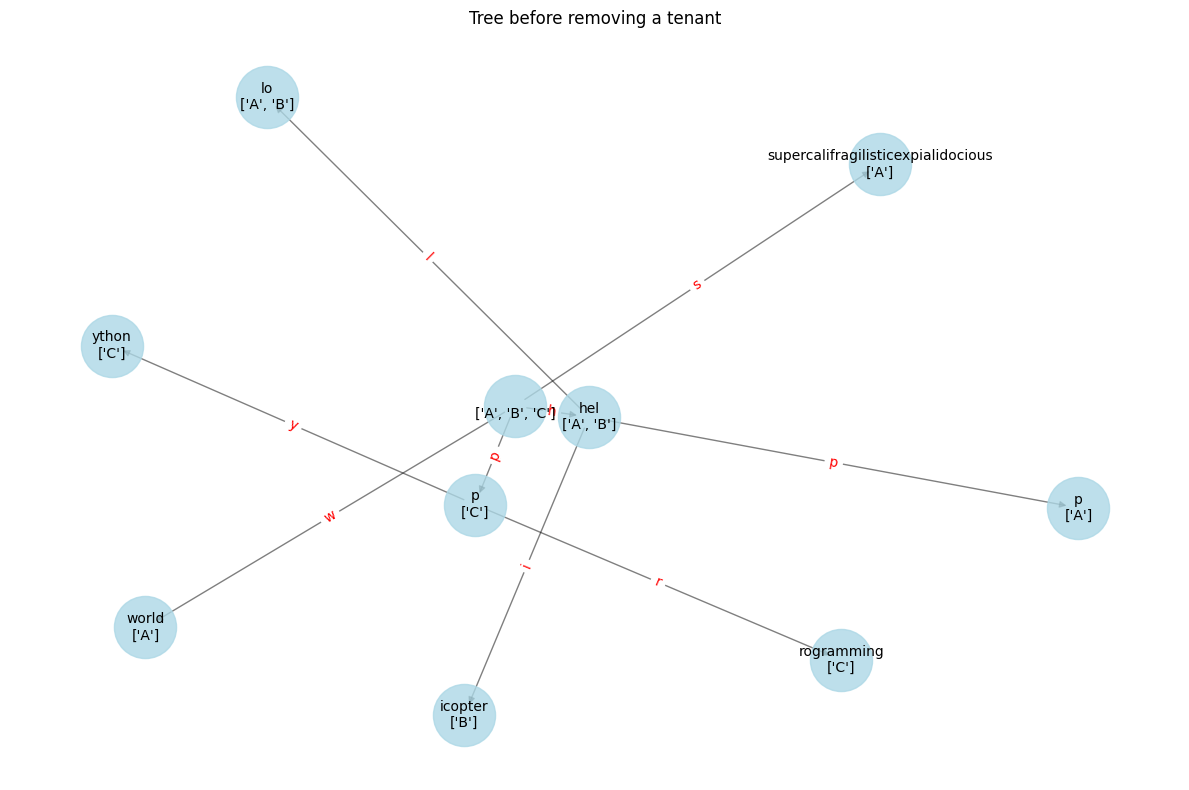


After removing tenant B:


,Tenant,Character Count,Percentage
0,A,26,61.900000
1,C,16,38.100000


Smallest tenant: C


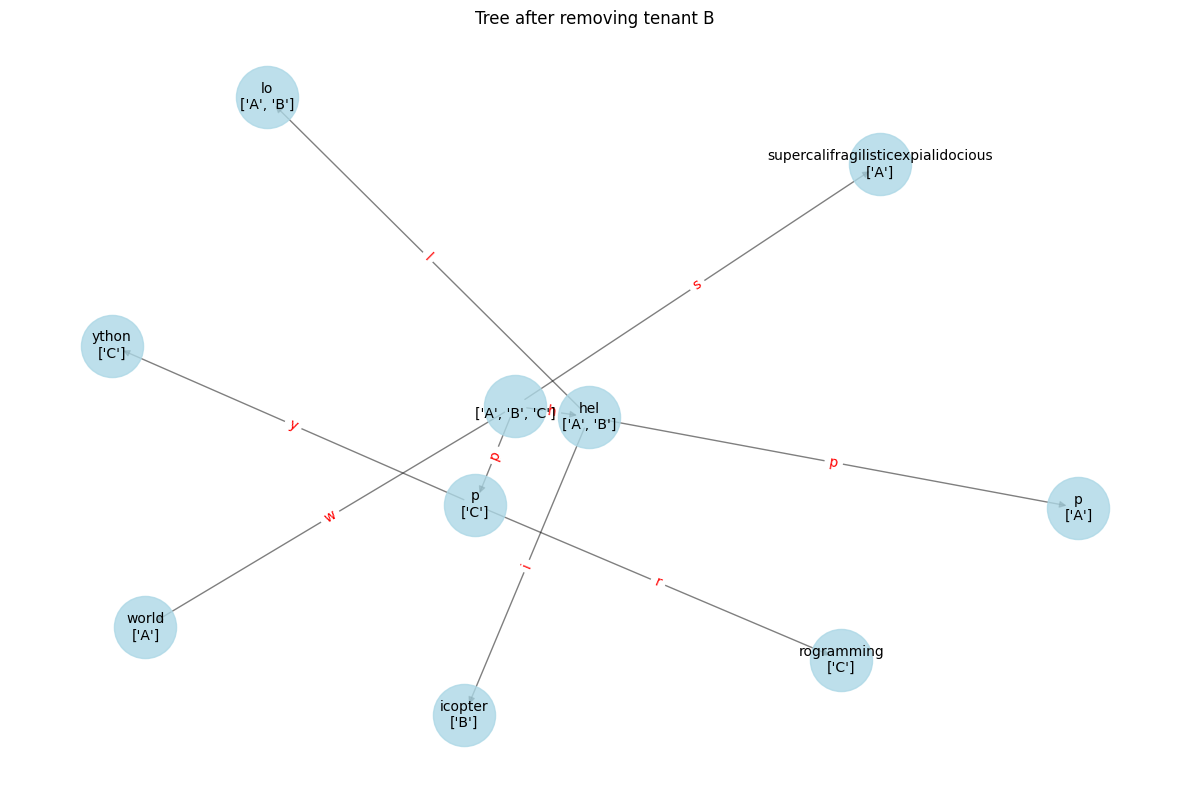

In [7]:
# Check current tenants
print("Before removing tenant:")
display_tenant_stats(tree)
visualize_tree(tree, "Tree before removing a tenant")

# Remove tenant B
tenant_to_remove = "B"
tree.remove_tenant(tenant_to_remove)

print(f"\nAfter removing tenant {tenant_to_remove}:")
display_tenant_stats(tree)
visualize_tree(tree, f"Tree after removing tenant {tenant_to_remove}")

## 6. Complex Example with Real Text

,Tenant,Character Count,Percentage
0,Tech,173,37.120000
1,News,159,34.120000
2,Literature,134,28.760000


Smallest tenant: Literature


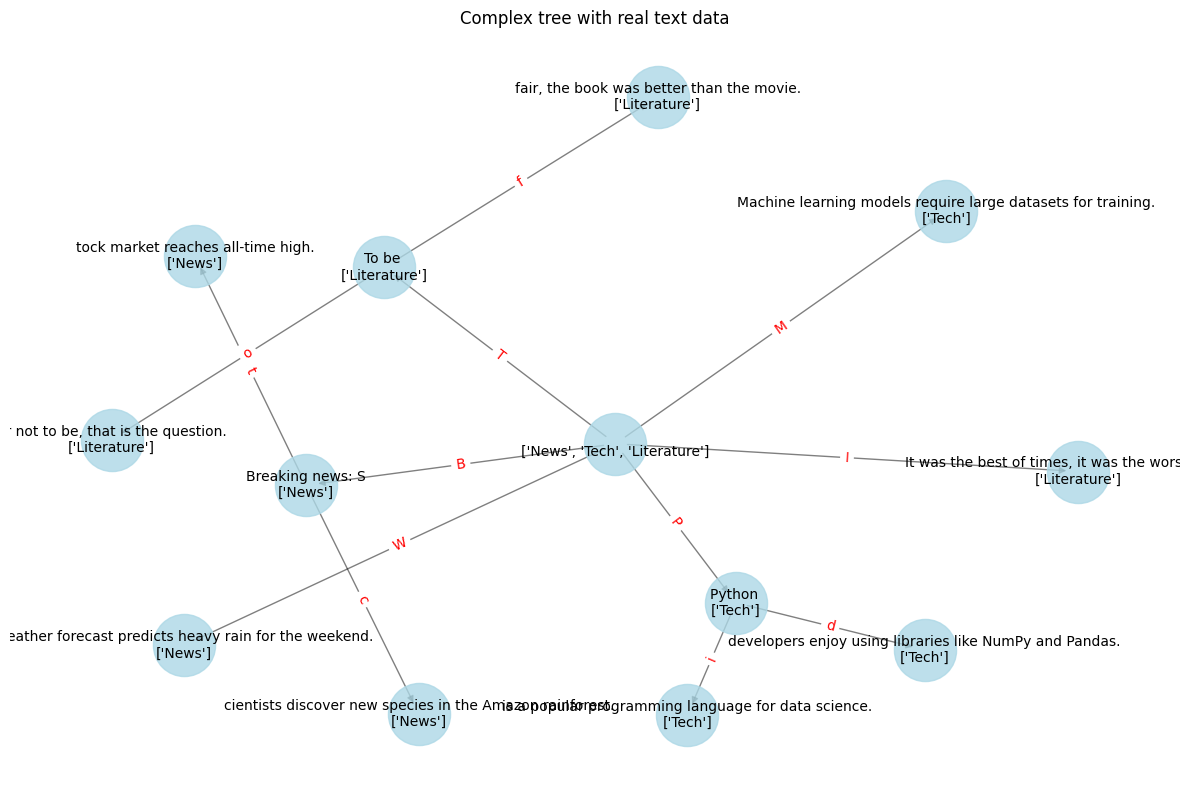


Prefix matching with real text:
Input: 'Breaking news:' → Matched: 'Breaking news:' (Tenant: News)
Input: 'Python' → Matched: 'Python' (Tenant: Tech)
Input: 'To be' → Matched: 'To be' (Tenant: Literature)
Input: 'It was the' → Matched: 'It was the' (Tenant: Literature)
Input: 'Weather' → Matched: 'Weather' (Tenant: News)
Input: 'Machine' → Matched: 'Machine' (Tenant: Tech)

Tenant-specific matching:

Matching for tenant News:
Input: 'Breaking news:' → Matched: 'Breaking news:'
Input: 'Python' → Matched: ''
Input: 'To be' → Matched: ''
Input: 'It was the' → Matched: ''
Input: 'Weather' → Matched: 'Weather'
Input: 'Machine' → Matched: ''

Matching for tenant Tech:
Input: 'Breaking news:' → Matched: ''
Input: 'Python' → Matched: 'Python'
Input: 'To be' → Matched: ''
Input: 'It was the' → Matched: ''
Input: 'Weather' → Matched: ''
Input: 'Machine' → Matched: 'Machine'

Matching for tenant Literature:
Input: 'Breaking news:' → Matched: ''
Input: 'Python' → Matched: ''
Input: 'To be' → Matc

In [9]:
# Create a new tree for a more complex example
complex_tree = Tree()

# Sample sentences for different tenants
tenant_data = {
    "News": [
        "Breaking news: Scientists discover new species in the Amazon rainforest.",
        "Breaking news: Stock market reaches all-time high.",
        "Weather forecast predicts heavy rain for the weekend."
    ],
    "Tech": [
        "Python is a popular programming language for data science.",
        "Python developers enjoy using libraries like NumPy and Pandas.",
        "Machine learning models require large datasets for training."
    ],
    "Literature": [
        "To be or not to be, that is the question.",
        "To be fair, the book was better than the movie.",
        "It was the best of times, it was the worst of times."
    ]
}

# Insert all sentences into the tree
for tenant, sentences in tenant_data.items():
    for sentence in sentences:
        complex_tree.insert(sentence, tenant)

# Display tenant statistics
display_tenant_stats(complex_tree)

# Visualize the complex tree
visualize_tree(complex_tree, "Complex tree with real text data")

# Test prefix matching with partial inputs
test_prefixes = [
    "Breaking news:",
    "Python",
    "To be",
    "It was the",
    "Weather",
    "Machine"
]

print("\nPrefix matching with real text:")
for prefix in test_prefixes:
    matched_text, tenant = complex_tree.prefix_match(prefix)
    print(f"Input: '{prefix}' → Matched: '{matched_text}' (Tenant: {tenant})")

# Test tenant-specific matching
print("\nTenant-specific matching:")
for tenant in tenant_data.keys():
    print(f"\nMatching for tenant {tenant}:")
    for prefix in test_prefixes:
        matched_text = complex_tree.prefix_match_tenant(prefix, tenant)
        print(f"Input: '{prefix}' → Matched: '{matched_text}'")

## 7. Performance Analysis

In [11]:
import random
import string
import time

def generate_random_string(length):
    """Generate a random string of fixed length."""
    import string  # Import the string module
    letters = string.ascii_lowercase
    return ''.join(random.choice(letters) for _ in range(length))

# Create a new tree for performance testing
perf_tree = Tree()

# Parameters for performance testing
num_tenants = 5
strings_per_tenant = 100
string_length = 20
num_queries = 1000

# Generate random strings for each tenant
tenant_strings = {}
for i in range(num_tenants):
    tenant = f"Tenant_{i}"
    tenant_strings[tenant] = [
        generate_random_string(string_length) 
        for _ in range(strings_per_tenant)
    ]

# Measure insertion time
start_time = time.time()
for tenant, strings in tenant_strings.items():
    for string in strings:
        perf_tree.insert(string, tenant)
insertion_time = time.time() - start_time

print(f"Inserted {num_tenants * strings_per_tenant} strings in {insertion_time:.4f} seconds")
print(f"Average insertion time: {(insertion_time / (num_tenants * strings_per_tenant)) * 1000:.4f} ms")

# Prepare query strings (mix of existing and new strings)
query_strings = []
for _ in range(num_queries // 2):
    # Select a random existing string
    tenant = random.choice(list(tenant_strings.keys()))
    string = random.choice(tenant_strings[tenant])
    prefix_length = random.randint(5, len(string))
    query_strings.append(string[:prefix_length])

for _ in range(num_queries // 2):
    # Generate a new random string
    query_strings.append(generate_random_string(random.randint(5, string_length)))

# Measure query time
start_time = time.time()
for query in query_strings:
    matched_text, tenant = perf_tree.prefix_match(query)
query_time = time.time() - start_time

print(f"Performed {num_queries} queries in {query_time:.4f} seconds")
print(f"Average query time: {(query_time / num_queries) * 1000:.4f} ms")

# Display tenant statistics
display_tenant_stats(perf_tree)

Inserted 500 strings in 0.0839 seconds
Average insertion time: 0.1678 ms
Performed 1000 queries in 0.0031 seconds
Average query time: 0.0031 ms


,Tenant,Character Count,Percentage
0,Tenant_3,1923,20.050000
1,Tenant_4,1923,20.050000
2,Tenant_0,1916,19.970000
3,Tenant_1,1916,19.970000
4,Tenant_2,1914,19.950000


Smallest tenant: Tenant_2


## 8. Summary and Conclusions

In this notebook, we've explored the multi-tenant prefix tree (radix tree) implementation. Here's what we've learned:

1. **Tree Structure**: The tree efficiently stores strings with shared prefixes, reducing storage requirements.
2. **Multi-Tenant Support**: The tree can store data for multiple tenants simultaneously, with each node tracking which tenants it belongs to.
3. **Prefix Matching**: The tree provides efficient prefix matching, both for any tenant and for specific tenants.
4. **Tenant Management**: The tree supports operations like finding the smallest tenant and evicting tenants based on size constraints.
5. **Performance**: The tree provides efficient insertion and query operations, making it suitable for real-time applications.

Key features of this implementation:
- Thread-safe with node-level locking
- Support for tenant-specific operations
- Efficient memory usage through prefix sharing
- LRU-based eviction for managing memory constraints

This data structure is particularly useful for applications like autocomplete, spell checking, and routing in multi-tenant environments.